<div class="alert alert-success">
<font color='black'>
    
# ORIGINAL GAS IN-PLACE (OGIP)
  
Probabilistic estimation. <br>

</font>
</div>

In [1]:
from scipy.stats import lognorm, norm, truncnorm
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, Javascript, display_html, HTML 

display(HTML("<style>.cm-s-ipython span.cm-comment { color: darkblue; }</style>")) # Comments color = blue

import import_ipynb # Library to call costume functions
import OGIP_py_Functions as my_Func

# Set input values to generate samples and distributions
### Rock volume, NTG, Porosity, Water Saturation, Eg, etc.

Stats,Rock_Vol,NTG,Porosity,Sw,Eg,RFg,Merma,CGR,RFo
Samples,10000.0,10000.0000,10000.0000,10000.0000,10000.0,10000.000,10000.000,10000.0,10000.000
Mean,8636.3,0.5272,0.0553,0.3556,324.7,0.649,0.895,18.3,0.574
SD,2625.1,0.0973,0.0190,0.1108,43.2,0.087,0.055,1.4,0.217
Min,4057.7,0.1670,0.0100,0.1000,250.0,0.500,0.800,15.1,0.200
P99,4445.2,0.2990,0.0150,0.1260,251.6,0.503,0.801,15.4,0.207
P90,5532.6,0.4040,0.0310,0.2120,264.9,0.529,0.819,16.5,0.273
P75,6497.8,0.4610,0.0420,0.2770,287.0,0.573,0.848,17.3,0.385
P50,8216.5,0.5270,0.0550,0.3530,325.2,0.648,0.896,18.3,0.574
P25,10491.7,0.5930,0.0680,0.4300,362.3,0.723,0.944,19.3,0.761
P10,12553.2,0.6520,0.0800,0.5000,384.2,0.769,0.971,20.3,0.875


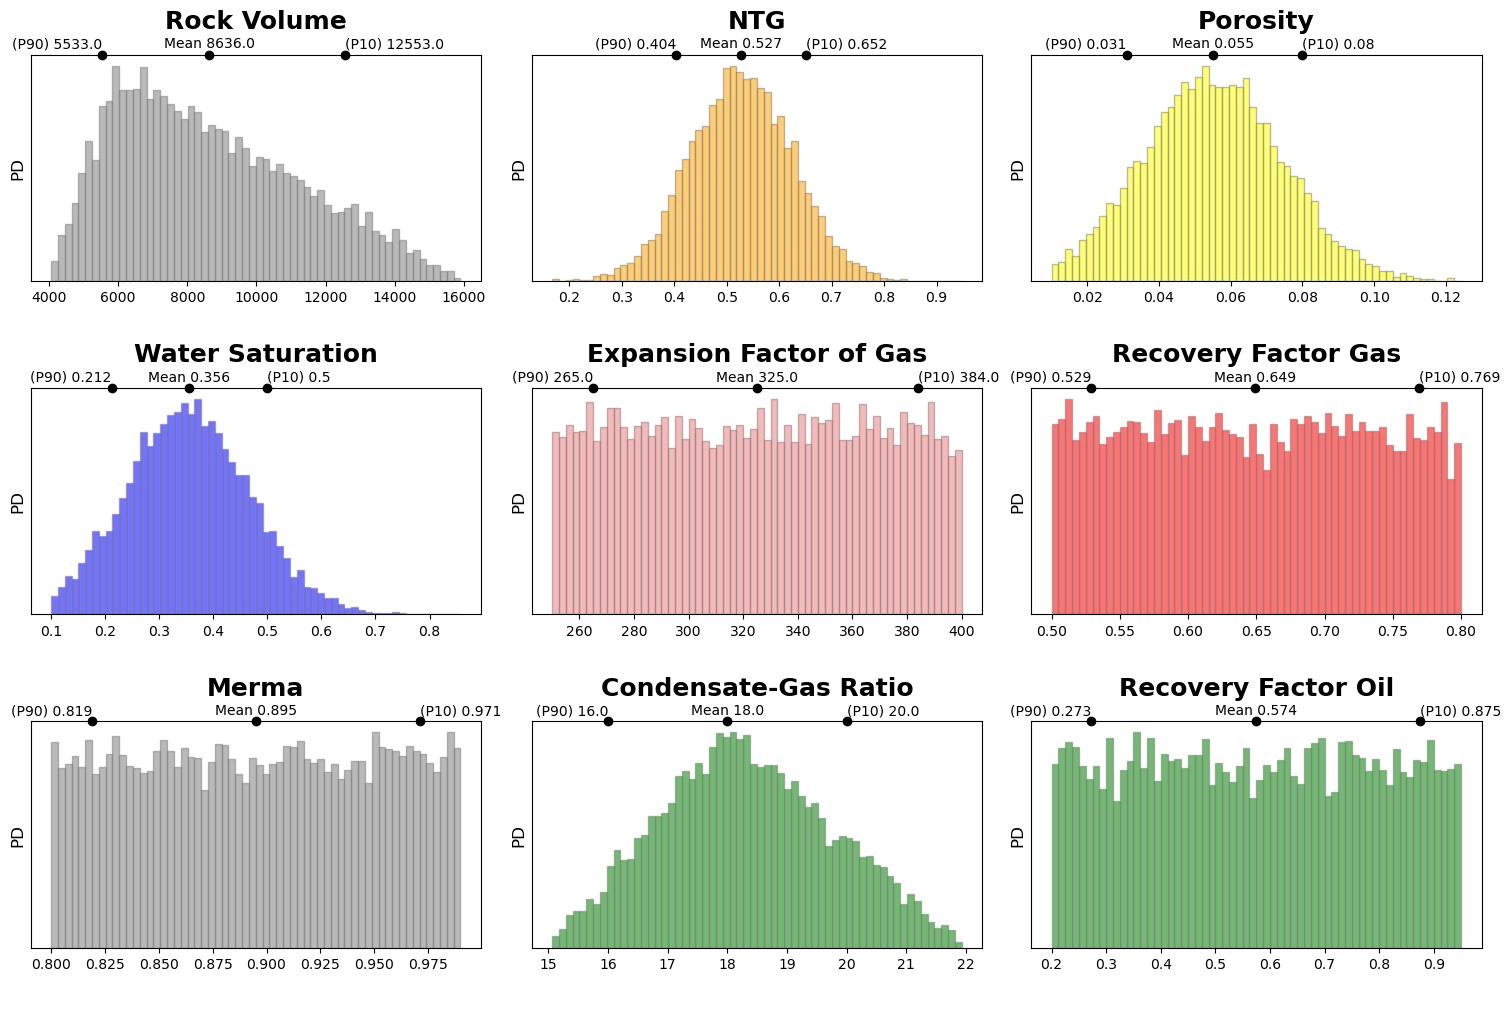

In [2]:
Input_var_dict ={}

Dist_Type,var_label, val_Const = 'Triangular', 'Rock Volume', 5000
low, high, val_Mode = 4000, 16000, 6000                   
val_P90, val_P10 = 2000, 5000          
Input_var_dict['Rock_Vol'] = [Dist_Type, var_label, val_Const, low, high, val_Mode, val_P90, val_P10]

Dist_Type,var_label, val_Const = 'Normal', 'NTG', 0.5
low, high, val_Mode = 0.01, 0.95, 0.5                  
val_P90, val_P10 = 0.4, 0.65         
Input_var_dict['NTG'] = [Dist_Type, var_label, val_Const, low, high, val_Mode, val_P90, val_P10]

Dist_Type,var_label, val_Const = 'Normal', 'Porosity', 0.1
low, high, val_Mode = 0.01, 0.2, 0.07                  
val_P90, val_P10 = 0.03, 0.08        
Input_var_dict['Porosity'] = [Dist_Type, var_label, val_Const, low, high, val_Mode, val_P90, val_P10]

Dist_Type,var_label, val_Const = 'Normal', 'Water Saturation', 0.5
low, high, val_Mode = 0.1, 1, 0.5                   
val_P90, val_P10 = 0.2, 0.5          
Input_var_dict['Sw'] = [Dist_Type, var_label, val_Const, low, high, val_Mode, val_P90, val_P10]
                
Dist_Type,var_label, val_Const = 'Uniform', 'Expansion Factor of Gas', 300
low, high, val_Mode = 250, 400, 350                  
val_P90, val_P10 = 270, 320          
Input_var_dict['Eg'] = [Dist_Type, var_label, val_Const, low, high, val_Mode, val_P90, val_P10]

               
Dist_Type,var_label, val_Const = 'Uniform', 'Recovery Factor Gas', 0.6
low, high, val_Mode = 0.5, 0.8, 0.6                  
val_P90, val_P10 = 0.4, 0.8          
Input_var_dict['RFg'] = [Dist_Type, var_label, val_Const, low, high, val_Mode, val_P90, val_P10]

Dist_Type,var_label, val_Const = 'Uniform', 'Merma', 0.95
low, high, val_Mode = 0.8, 0.99, 0.95             
val_P90, val_P10 = 0.95, 0.97          
Input_var_dict['Merma'] = [Dist_Type, var_label, val_Const, low, high, val_Mode, val_P90, val_P10]
                
Dist_Type,var_label, val_Const = 'Triangular', 'Condensate-Gas Ratio', 22
low, high, val_Mode = 15, 22, 18                   
val_P90, val_P10 = 20, 30          
Input_var_dict['CGR'] = [Dist_Type, var_label, val_Const, low, high, val_Mode, val_P90, val_P10]
                
Dist_Type,var_label, val_Const = 'Uniform', 'Recovery Factor Oil', 0.6
low, high, val_Mode = 0.2, 0.95, 0.6                  
val_P90, val_P10 = 0.4, 0.8            
Input_var_dict['RFo'] = [Dist_Type, var_label, val_Const, low, high, val_Mode, val_P90, val_P10]

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(15,10), layout ='constrained')

Input_df,Input_Stats_df = my_Func.Generate_Samples_and_Plot_Distribution(Input_var_dict,ax)
display(Input_Stats_df)

# Calculate OGIP using input samples

Stats,OGIP_Bcf,Gas_Prod_Bcf,Gas_sale,OOIP
Samples,10000.0,10000.0,10000.0,10000.0
Mean,1862.3,1208.2,1081.8,34126.8
SD,1057.4,712.7,641.9,19615.9
Min,161.5,104.0,84.1,3030.1
P99,338.4,209.1,184.1,6105.5
P90,752.1,476.9,423.2,13667.3
P75,1108.6,700.9,623.9,20097.0
P50,1632.3,1053.5,942.0,29852.6
P25,2391.7,1546.1,1379.5,43771.2
P10,3286.9,2166.2,1949.9,60205.0


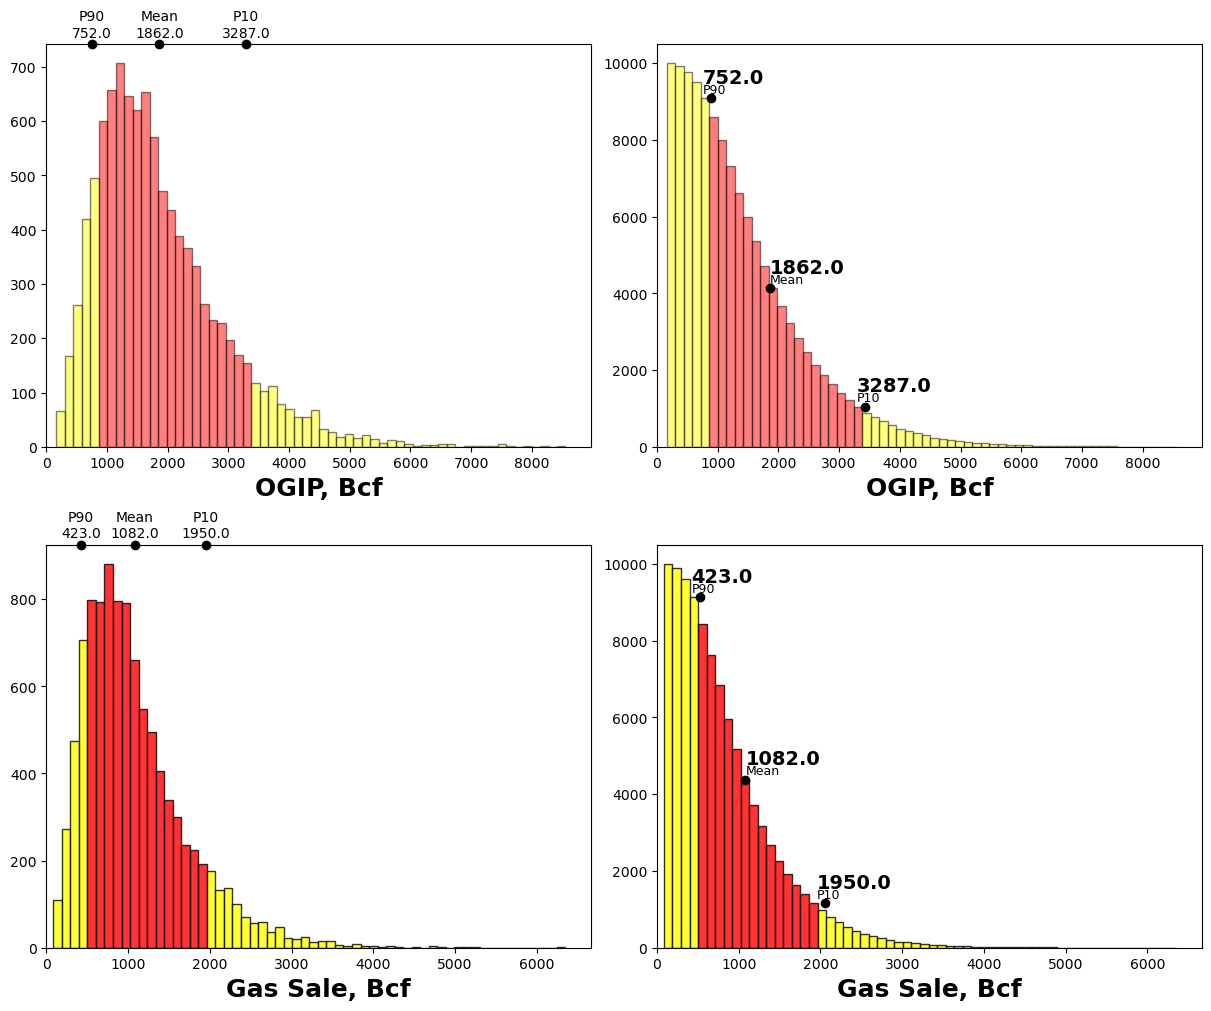

In [3]:
OGIP_arr, Gas_Prod_arr, Gas_sale_arr, OOIP_arr, Oil_Reserves_arr=[], [], [], [], [] #create empty arrays for solutions

i = 0
for index, row in Input_df.iterrows():
    Vrock_i, NTG_i, Poro_i, Sw_i = row['Rock_Vol'], row['NTG'], row['Porosity'], row['Sw']
    Eg_i, RFg_i, Merma_i, CGR_i, RFo_i = row['Eg'], row['RFg'], row['Merma'], row['CGR'], row['RFo']
    
    OGIP = (43560*((3.2808**3)/43560*1000000)*Vrock_i*Poro_i*NTG_i*(1-Sw_i)*Eg_i)/1000000000
    Gas_Prod, Gas_sale = OGIP * RFg_i, (OGIP * RFg_i) * Merma_i
    OOIP, Oil_Reserves = OGIP * CGR_i, (OGIP*CGR_i) * RFo_i
    
    OGIP_arr.append(OGIP), Gas_Prod_arr.append(Gas_Prod), Gas_sale_arr.append(Gas_sale)
    OOIP_arr.append(OOIP), Oil_Reserves_arr.append(Oil_Reserves)
    i = i +1

OGIP_df, OGIP_Stats_df = my_Func.generate_DF_and_Format_Table(Input_Stats_df,OGIP_arr,Gas_Prod_arr,Gas_sale_arr,OOIP_arr)

## Plot distributions
fig, ax2 = plt.subplots(nrows = 2, ncols=2, figsize=(12,10), layout ='constrained')

my_Func.Plot_OGIP(OGIP_df['OGIP_Bcf'],0,'OGIP, Bcf', ax2)
my_Func.Plot_OGIP(OGIP_df['Gas_sale'],1, 'Gas Sale, Bcf', ax2)

### Generate scatter plot for all variables against OGIP
### Calculate correlation and generate tornado plot

,OGIP
Porosity,0.600374
Rock_Vol,0.539096
NTG,0.330898
Eg,0.236217
Sw,-0.301146


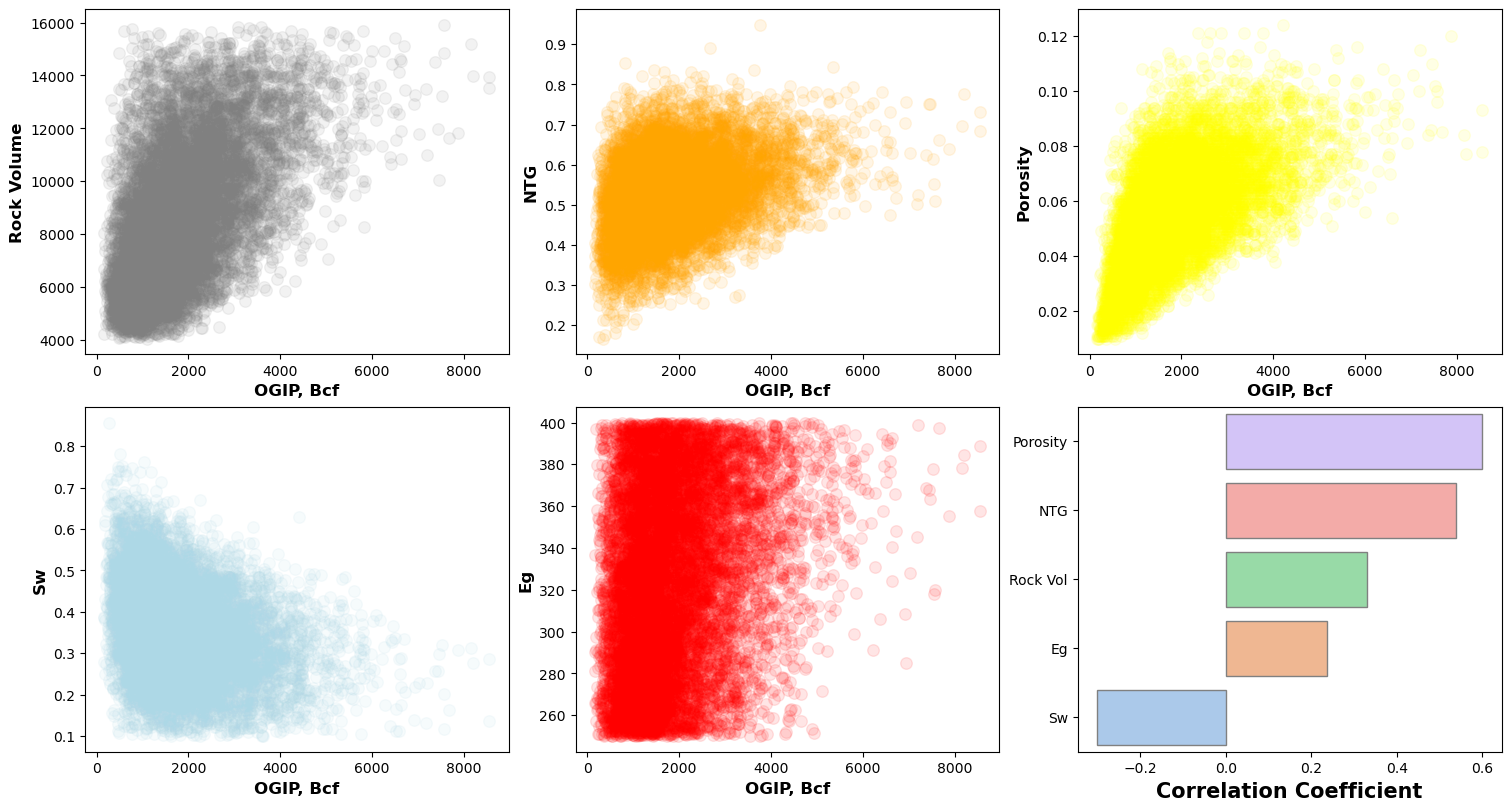

In [6]:

Input_df['OGIP'] = OGIP_df['OGIP_Bcf']

corr_DF_Coeff = Input_df.corr()


## Create Plots ##
fig, axSC= plt.subplots(nrows=2, ncols=3, figsize=(15,8), layout ='constrained')

my_Func.Plot_Scatter(Input_df['OGIP'],Input_df['Rock_Vol'],'Rock Volume','gray',0,0, axSC)
my_Func.Plot_Scatter(Input_df['OGIP'],Input_df['NTG'],'NTG','orange',0,1, axSC)
my_Func.Plot_Scatter(Input_df['OGIP'],Input_df['Porosity'],'Porosity','yellow',0,2, axSC)
my_Func.Plot_Scatter(Input_df['OGIP'],Input_df['Sw'],'Sw','lightblue',1,0, axSC)
my_Func.Plot_Scatter(Input_df['OGIP'],Input_df['Eg'],'Eg','red',1,1, axSC)


OGIP_Coeff = corr_DF_Coeff['OGIP']
OGIP_Coeff = OGIP_Coeff.drop('OGIP')
OGIP_Coeff = OGIP_Coeff.drop('RFo')
OGIP_Coeff = OGIP_Coeff.drop('Merma')
OGIP_Coeff = OGIP_Coeff.drop('CGR')
OGIP_Coeff = OGIP_Coeff.drop('RFg')

OGIP_Coeff.sort_values(ascending = False, axis=0,inplace=True)

OGIP_Coeff_df = pd.DataFrame(OGIP_Coeff)
display(OGIP_Coeff_df)

Input_Var_Names = ['Porosity','NTG','Rock Vol','Eg', 'Sw']
xx,yy = 1,2
sns.barplot(y=Input_Var_Names, x=OGIP_Coeff, ax=axSC[xx,yy], orient="h", hue=OGIP_Coeff, palette='pastel',edgecolor='gray', legend=False);
axSC[xx,yy].set_xlabel('Correlation Coefficient', fontsize = 15,weight='bold');